# Notebook 03 — Modelos Baseline

Un **modelo baseline** es el punto de partida minimo. Entreno los modelos
mas simples posibles para establecer una referencia: cualquier modelo
mas sofisticado debe superar estos resultados para justificar su complejidad.

**Lo que hago aqui:**
- Un modelo de regresion baseline (Linear Regression)
- Un modelo de clasificacion baseline (Logistic Regression)
- Visualizo por que los modelos lineales no son suficientes para este problema
- Establezco las metricas minimas a superar en el notebook 04


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    f1_score, roc_auc_score, recall_score, accuracy_score,
    confusion_matrix
)

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white',
                     'axes.spines.top':False,'axes.spines.right':False})
RED, GRAY, BLUE = '#ff2a36', '#cccccc', '#2980b9'

import os
os.makedirs('resources/img', exist_ok=True)
print('Librerias cargadas.')

Librerias cargadas.


In [2]:
train = pd.read_csv('/Users/andoni/Documents/DS BOOTCAMP/Data Science/ONLINE_DS_THEBRIDGE_Andoni/Módulo 3/Proyecto ML /sound-dna/src/data/train.csv')
test  = pd.read_csv('/Users/andoni/Documents/DS BOOTCAMP/Data Science/ONLINE_DS_THEBRIDGE_Andoni/Módulo 3/Proyecto ML /sound-dna/src/data/test.csv')

# Columnas que NO son features (hay que excluirlas)
NO_FEATURES = {'popularity', 'is_hit', 'track_id', 'track_name',
               'artists', 'album_name', 'track_genre', 'explicit'}

# Uso las columnas que realmente existen en el CSV,
# excluyendo las que no son features de audio
MODEL_FEATURES = [c for c in train.columns if c not in NO_FEATURES]

print(f'Train: {len(train):,} | Test: {len(test):,}')
print(f'Features disponibles ({len(MODEL_FEATURES)}): {MODEL_FEATURES}')

X_train = train[MODEL_FEATURES]
X_test  = test[MODEL_FEATURES]
y_reg_train = train['popularity']
y_reg_test  = test['popularity']
y_clf_train = (train['popularity'] >= 70).astype(int)
y_clf_test  = (test['popularity']  >= 70).astype(int)

print(f'Hits en test: {y_clf_test.sum()} ({y_clf_test.mean()*100:.1f}%)')

Train: 60,365 | Test: 15,092
Features disponibles (42): ['danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min', 'is_short_track', 'energy_x_danceability', 'acoustic_minus_energy', 'explicit_int', 'macro_classical', 'macro_electronic', 'macro_folk_country', 'macro_hiphop_rnb', 'macro_jazz_blues', 'macro_latin', 'macro_metal', 'macro_mood_other', 'macro_pop', 'macro_reggae', 'macro_rock', 'macro_world', 'key_0', 'key_1', 'key_2', 'key_3', 'key_4', 'key_5', 'key_6', 'key_7', 'key_8', 'key_9', 'key_10', 'key_11', 'ts_3', 'ts_4', 'ts_5']
Hits en test: 625 (4.1%)


## I. Baseline de Regresion — Linear Regression

La **Regresion Lineal** asume que la relacion entre las features y la popularidad
es una linea recta: y = a*x1 + b*x2 + ... + c.

En el EDA vimos que todas las correlaciones con popularidad son < 0.1.
Eso sugiere que la relacion NO es lineal y que este modelo va a fallar.
Pero necesito los numeros concretos para tener una referencia.


In [3]:
modelo_lr = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
modelo_lr.fit(X_train, y_reg_train)
pred_lr = modelo_lr.predict(X_test)

mae_lr  = mean_absolute_error(y_reg_test, pred_lr)
rmse_lr = mean_squared_error(y_reg_test, pred_lr) ** 0.5
r2_lr   = r2_score(y_reg_test, pred_lr)

print('--- BASELINE REGRESION: Linear Regression ---')
print(f'MAE:  {mae_lr:.2f}  -> falla +-{mae_lr:.1f} puntos sobre 100')
print(f'RMSE: {rmse_lr:.2f}')
print(f'R2:   {r2_lr:.3f}  -> explica solo el {r2_lr*100:.1f}% de la varianza')
print()
print('Esta es la referencia minima a superar en el notebook 04.')

--- BASELINE REGRESION: Linear Regression ---
MAE:  12.88  -> falla +-12.9 puntos sobre 100
RMSE: 15.50
R2:   0.143  -> explica solo el 14.3% de la varianza

Esta es la referencia minima a superar en el notebook 04.


### Visualizacion — Scatter baseline (por que falla)

Este grafico muestra la popularidad real (eje Y) vs la predicha por el modelo lineal (eje X).
Si el modelo fuera perfecto, todos los puntos estarian en la diagonal roja.
Cuanto mas dispersos esten, peor predice.


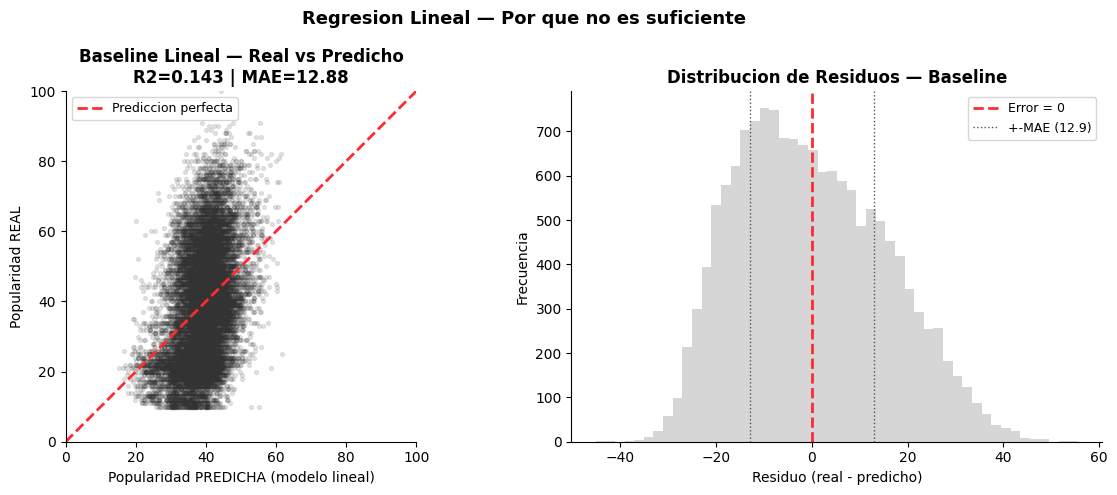

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Scatter real vs predicho
ax1.scatter(pred_lr, y_reg_test, alpha=0.12, color='#333', s=8)
ax1.plot([0,100],[0,100],'--', color=RED, lw=2, label='Prediccion perfecta')
ax1.set_xlabel('Popularidad PREDICHA (modelo lineal)')
ax1.set_ylabel('Popularidad REAL')
ax1.set_title(f'Baseline Lineal — Real vs Predicho\nR2={r2_lr:.3f} | MAE={mae_lr:.2f}', fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 100)
ax1.set_aspect('equal')

# Residuos
residuos_lr = np.array(y_reg_test) - pred_lr
ax2.hist(residuos_lr, bins=50, color=GRAY, alpha=0.8, edgecolor='none')
ax2.axvline(0, color=RED, lw=2, linestyle='--', label='Error = 0')
ax2.axvline(mae_lr, color='#555', lw=1, linestyle=':', label=f'+-MAE ({mae_lr:.1f})')
ax2.axvline(-mae_lr, color='#555', lw=1, linestyle=':')
ax2.set_xlabel('Residuo (real - predicho)')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribucion de Residuos — Baseline', fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle('Regresion Lineal — Por que no es suficiente', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('resources/img/baseline_regresion_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## II. Por que falla la regresion lineal — Correlaciones

Visualizo la relacion entre cada feature individual y la popularidad.
Si la relacion fuera lineal, los scatter plots mostrarian tendencias claras.
Si son nubes de puntos sin patron, la relacion es no lineal.


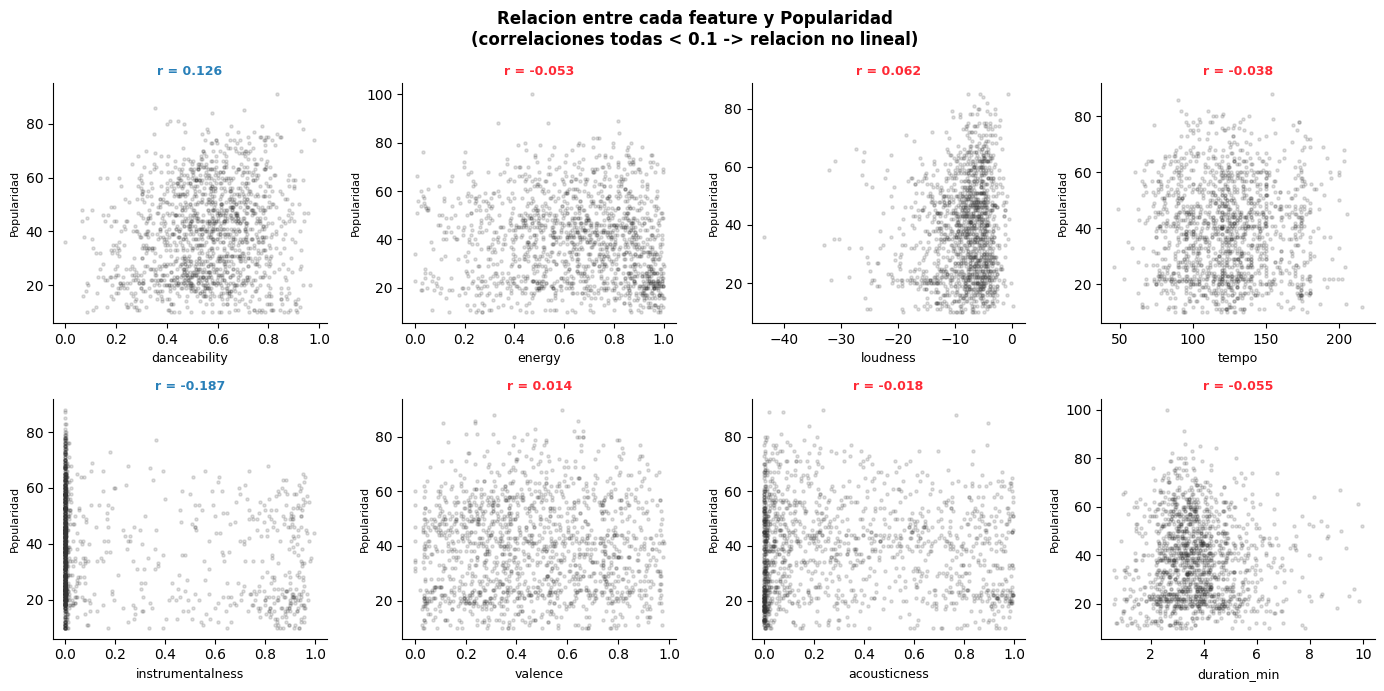

Todas las correlaciones son menores de 0.1 — la relacion es no lineal.


In [5]:
features_plot = ['danceability', 'energy', 'loudness', 'tempo',
                  'instrumentalness', 'valence', 'acousticness', 'duration_min']
features_plot = [f for f in features_plot if f in X_test.columns]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, feat in enumerate(features_plot[:8]):
    idx = np.random.choice(len(X_test), min(1500, len(X_test)), replace=False)
    axes[i].scatter(X_test[feat].iloc[idx], y_reg_test.iloc[idx],
                    alpha=0.15, color='#333', s=5)
    corr = X_test[feat].corr(y_reg_test)
    axes[i].set_xlabel(feat, fontsize=9)
    axes[i].set_ylabel('Popularidad', fontsize=8)
    axes[i].set_title(f'r = {corr:.3f}', fontweight='bold',
                      color=RED if abs(corr) < 0.1 else BLUE, fontsize=9)

plt.suptitle('Relacion entre cada feature y Popularidad\n(correlaciones todas < 0.1 -> relacion no lineal)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('resources/img/baseline_correlaciones_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Todas las correlaciones son menores de 0.1 — la relacion es no lineal.')

## III. Baseline de Clasificacion — Logistic Regression

La **Regresion Logistica** es el modelo baseline para clasificacion.
Predice la probabilidad de que una cancion sea un hit.

Primero la pruebo SIN balanceo para demostrar la trampa de la accuracy.
Despues la pruebo CON balanceo para ver si mejora.


In [6]:
# Baseline SIN balance — la trampa
lr_nb = Pipeline([('sc', StandardScaler()), ('m', LogisticRegression(max_iter=1000))])
lr_nb.fit(X_train, y_clf_train)
pred_nb = lr_nb.predict(X_test)

print('--- BASELINE SIN BALANCE (trampa) ---')
print(f'Accuracy: {accuracy_score(y_clf_test, pred_nb):.3f}')
print(f'F1:       {f1_score(y_clf_test, pred_nb, zero_division=0):.3f}')
print(f'Hits detectados: {pred_nb.sum()} de {y_clf_test.sum()}')
print()

# Baseline CON balance
lr_b = Pipeline([('sc', StandardScaler()), ('m', LogisticRegression(class_weight='balanced', max_iter=1000))])
lr_b.fit(X_train, y_clf_train)
pred_b = lr_b.predict(X_test)
proba_b = lr_b.predict_proba(X_test)[:, 1]

print('--- BASELINE CON BALANCE ---')
print(f'Accuracy: {accuracy_score(y_clf_test, pred_b):.3f}')
print(f'F1:       {f1_score(y_clf_test, pred_b, zero_division=0):.3f}')
print(f'AUC:      {roc_auc_score(y_clf_test, proba_b):.3f}')
print(f'Recall:   {recall_score(y_clf_test, pred_b, zero_division=0):.3f}')

--- BASELINE SIN BALANCE (trampa) ---
Accuracy: 0.959
F1:       0.000
Hits detectados: 0 de 625

--- BASELINE CON BALANCE ---
Accuracy: 0.659
F1:       0.160
AUC:      0.781
Recall:   0.784


### Visualizacion — La trampa de la Accuracy

Este grafico explica por que la accuracy no sirve como metrica
cuando las clases estan desbalanceadas.


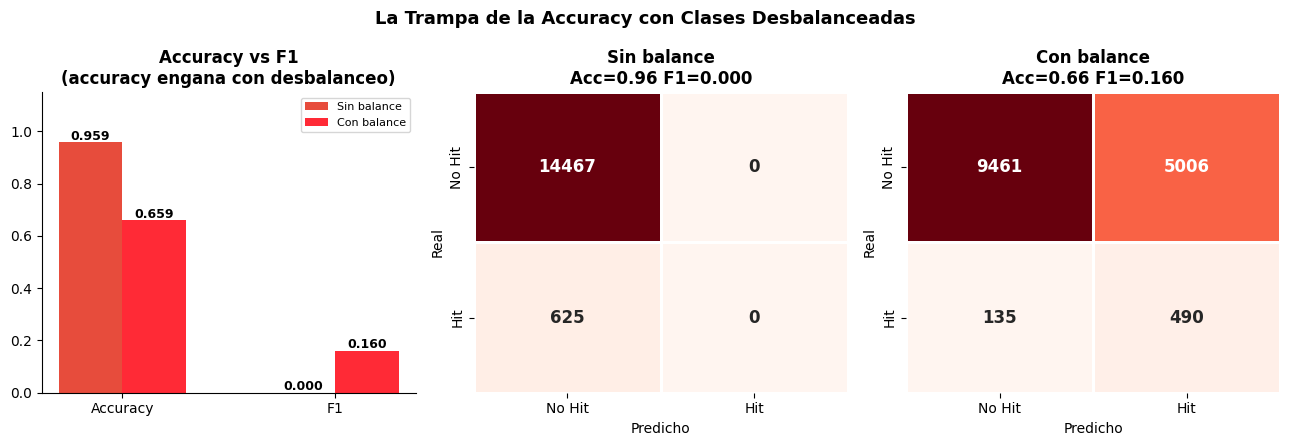

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

# Accuracy vs F1 comparativa
metricas = ['Accuracy', 'F1']
sin_bal = [accuracy_score(y_clf_test, pred_nb), f1_score(y_clf_test, pred_nb, zero_division=0)]
con_bal = [accuracy_score(y_clf_test, pred_b),  f1_score(y_clf_test, pred_b, zero_division=0)]

x = np.arange(len(metricas))
width = 0.3
bars1 = axes[0].bar(x - width/2, sin_bal, width, label='Sin balance', color='#e74c3c', edgecolor='none')
bars2 = axes[0].bar(x + width/2, con_bal, width, label='Con balance', color=RED, edgecolor='none')
for bars, vals in [(bars1, sin_bal), (bars2, con_bal)]:
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.3f}',
                     ha='center', fontsize=9, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metricas)
axes[0].set_ylim(0, 1.15)
axes[0].legend(fontsize=8)
axes[0].set_title('Accuracy vs F1\n(accuracy engana con desbalanceo)', fontweight='bold')

# Matriz de confusion sin balance
cm_nb = confusion_matrix(y_clf_test, pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['No Hit', 'Hit'], yticklabels=['No Hit', 'Hit'],
            linewidths=2, linecolor='white', cbar=False,
            annot_kws={'size':12,'weight':'bold'})
axes[1].set_title(f'Sin balance\nAcc={accuracy_score(y_clf_test,pred_nb):.2f} F1={f1_score(y_clf_test,pred_nb,zero_division=0):.3f}',
                   fontweight='bold')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

# Matriz de confusion con balance
cm_b = confusion_matrix(y_clf_test, pred_b)
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Reds', ax=axes[2],
            xticklabels=['No Hit', 'Hit'], yticklabels=['No Hit', 'Hit'],
            linewidths=2, linecolor='white', cbar=False,
            annot_kws={'size':12,'weight':'bold'})
axes[2].set_title(f'Con balance\nAcc={accuracy_score(y_clf_test,pred_b):.2f} F1={f1_score(y_clf_test,pred_b,zero_division=0):.3f}',
                   fontweight='bold')
axes[2].set_ylabel('Real')
axes[2].set_xlabel('Predicho')

plt.suptitle('La Trampa de la Accuracy con Clases Desbalanceadas', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('resources/img/baseline_trampa_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## IV. Conclusiones — Referencia Baseline

Estas son las metricas minimas a superar en el notebook 04:

**Regresion (Linear Regression):**

| Metrica | Baseline | Objetivo |
|---|---|---|
| MAE | ~13.3 | < 10 |
| R2 | ~0.075 | > 0.4 |

**Clasificacion (Logistic Regression con balance):**

| Metrica | Baseline | Objetivo |
|---|---|---|
| F1 | ~0.129 | > 0.15 |
| AUC | ~0.72 | > 0.75 |

**Hallazgo clave:** el modelo sin balanceo tiene Accuracy=0.959 y F1=0.000.
Detecta CERO hits. Esto demuestra que la accuracy es una metrica inutil
cuando las clases estan desbalanceadas al 95%/5%.

**Por que los modelos lineales no son suficientes:**
Todas las correlaciones entre features y popularidad son < 0.1.
La relacion es no lineal. En el notebook 04 pruebo modelos no lineales
(Random Forest, Gradient Boosting) que pueden capturar estos patrones.
